# Toy Example of S-phase Copy Number Replication Normalization

May 24, 2024

## Goal:
Create a procedure to make clear the copy number correction process

## Inputs:
- Raw gene expression reads
- Replication timing profile (deconvolved time, more granular than the experiment)
- H matrix with information on how much of each cell has progressed through the cell cycle.



In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


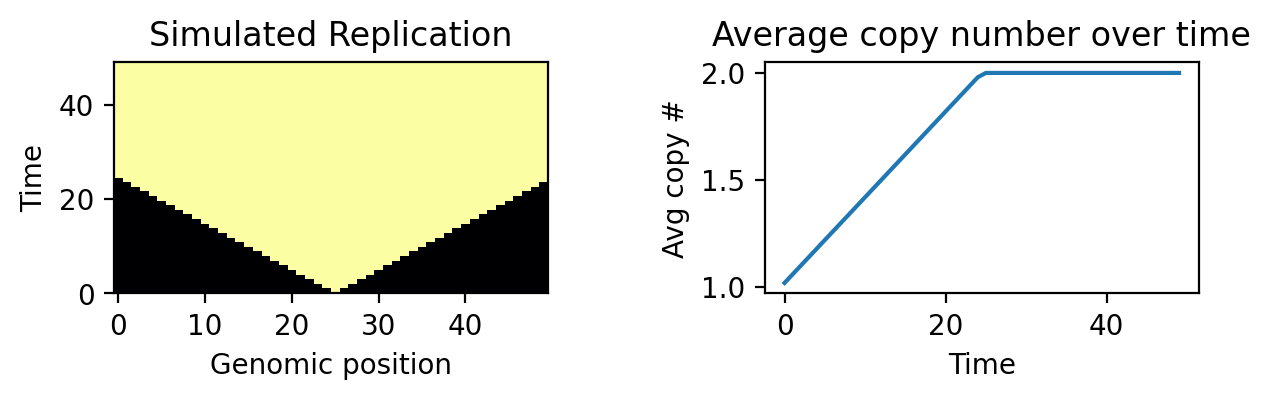

In [416]:
from src.ToyReplication import ToyReplication

# Let's create a replication profile with the dimensions of H
from src.delta_config import load_yl_delta_config
from src.helpers import calcH

length_timecourse = 50
step_min = 10 # Progress time by 10 minutes

# So the replication profile will have 79 timepoints
deconv_tps = np.arange(0, length_timecourse, 1)

n = 50 # 100, 10 kb windows
origins = {
    0:[25],
}

# Replication profile 
toy_repl_example = ToyReplication(n=n, timepoints=deconv_tps, origins=origins)
toy_repl_example.replicate()
toy_repl_example.plot_replication()


In [423]:
tps = np.arange(0, length_timecourse, step_min)
observed_reads = np.ones((len(tps), n))

In [424]:
toy_repl_example.set_reads(observed_reads, tps)
toy_repl_example.copy_number_correction()

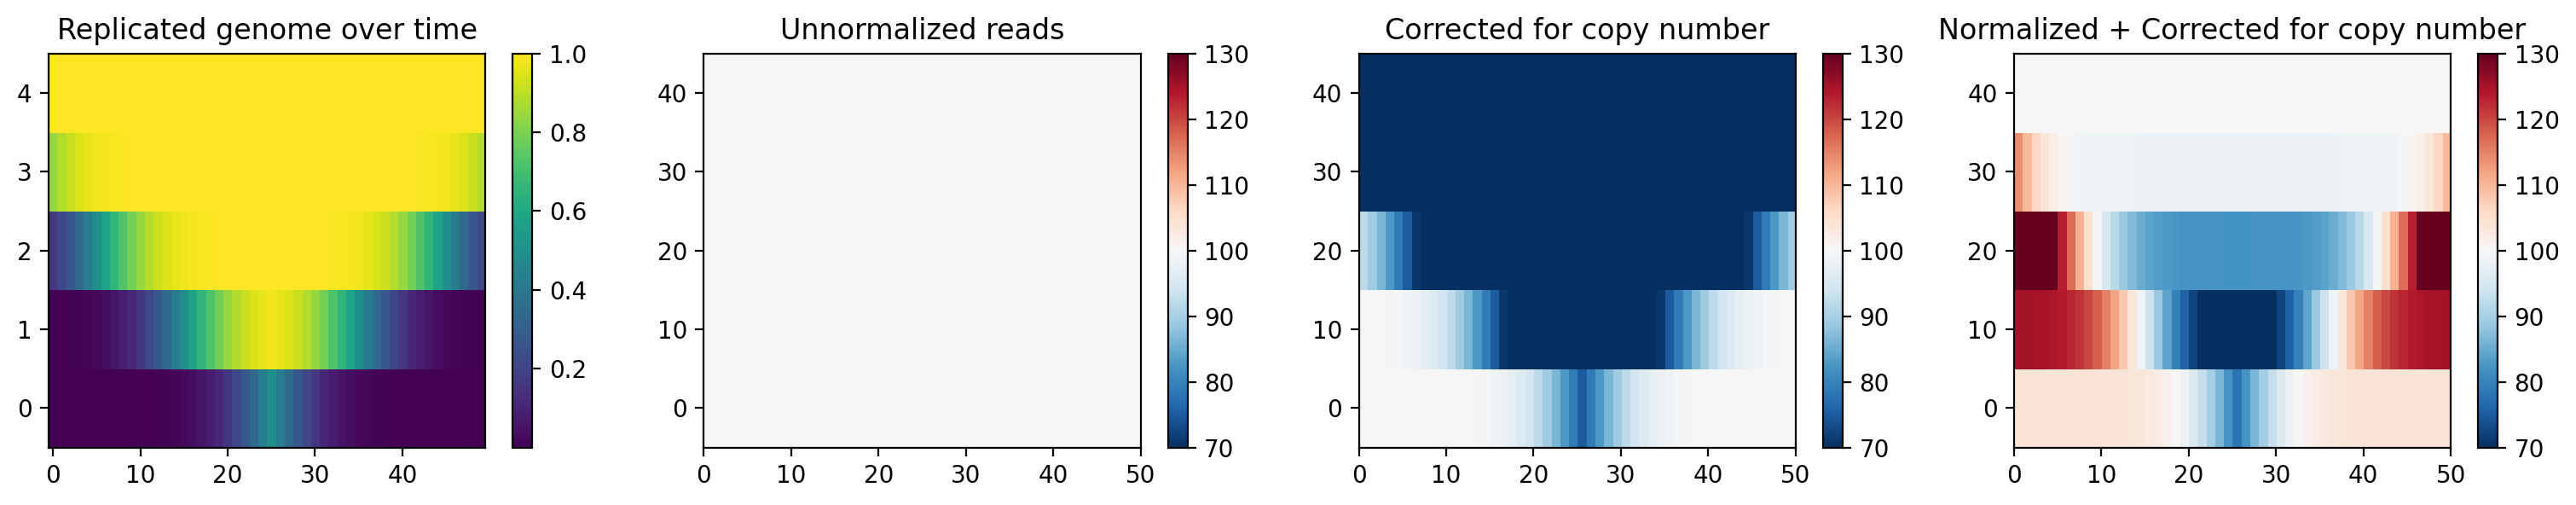

In [425]:
toy_repl_example.plot_correction()